In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score ,  accuracy_score
import math
from sklearn.datasets import make_blobs
np.random.seed(42)

In [17]:
X, y = make_blobs(
    n_samples=2500,
    centers=5,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

print(X.shape)
print(y.shape)

(2500, 2)
(2500,)


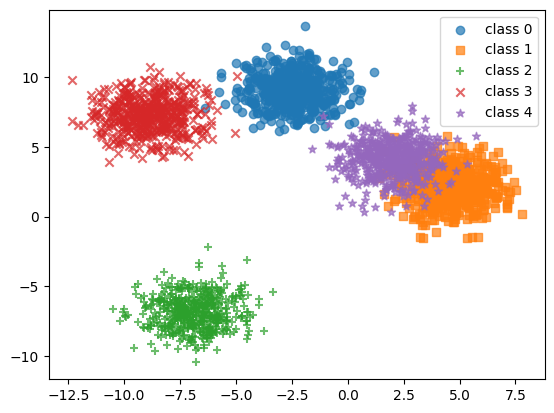

In [18]:
markers = ['o', 's', '+', 'x', '*']

for i in range(5):
    plt.scatter(
        X[y == i, 0],
        X[y == i, 1],
        marker=markers[i],
        label=f'class {i}',
        alpha=0.7
    )

plt.legend()
plt.show()

In [19]:
Xbar = np.concatenate(
    [np.ones((X.shape[0], 1)), X],
    axis=1
)

print(Xbar.shape)

(2500, 3)


In [22]:
def softmax_stable(Z):

    exp_Z = np.exp(
        Z - np.max(Z, axis=1, keepdims=True)
    )
    A = exp_Z / exp_Z.sum(axis=1, keepdims=True)
    return A

In [21]:
def convert_labels(y, K):
    Y = np.zeros((y.shape[0], K))
    for i in range(y.shape[0]):
        Y[i, y[i]] = 1
    return Y

In [23]:
def loss_function(X, Y, W):
    A = softmax_stable(X @ W)
    loss = -np.mean(
        np.sum(Y * np.log(A + 1e-8), axis=1)
    )
    return loss

In [31]:
K = 5
Y = convert_labels(y, K)
d = Xbar.shape[1]
W = 0.01 * np.random.randn(d, K)
lr = 0.05
epochs = 1000
loss_history = []
for epoch in range(epochs):
    A = softmax_stable(Xbar @ W)
    grad = Xbar.T @ (A - Y) / Xbar.shape[0]
    W -= lr * grad
    if epoch % 100 == 0:
        loss = loss_function(Xbar, Y, W)
        loss_history.append(loss)

        print(f"epoch {epoch} loss = {loss:.4f}")

epoch 0 loss = 1.1477
epoch 100 loss = 0.2737
epoch 200 loss = 0.2105
epoch 300 loss = 0.1820
epoch 400 loss = 0.1655
epoch 500 loss = 0.1545
epoch 600 loss = 0.1466
epoch 700 loss = 0.1406
epoch 800 loss = 0.1359
epoch 900 loss = 0.1321


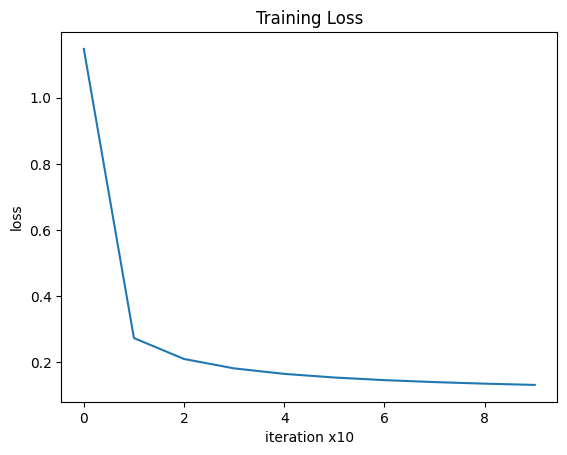

In [32]:
plt.plot(loss_history)
plt.xlabel("iteration x10")
plt.ylabel("loss")
plt.title("Training Loss")
plt.show()


In [33]:
def predict(X, W):
    probs = softmax_stable(X @ W)
    return np.argmax(probs, axis=1)

In [34]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_bar = np.concatenate(
    [np.ones((grid.shape[0], 1)), grid],
    axis=1
)
Z = predict(grid_bar, W)

Z = Z.reshape(xx.shape)

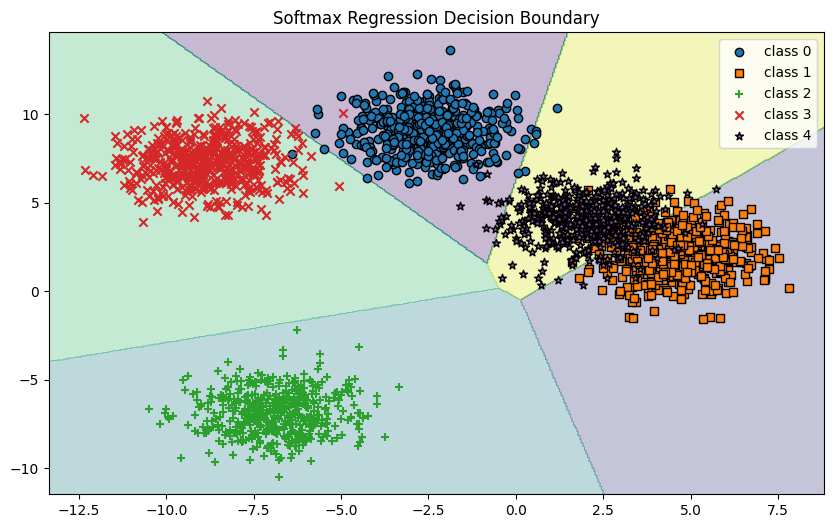

In [35]:
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
markers = ['o', 's', '+', 'x', '*']
for i in range(5):

    plt.scatter(
        X[y == i, 0],
        X[y == i, 1],
        marker=markers[i],
        label=f'class {i}',
        edgecolors='black'
    )
plt.legend()
plt.title("Softmax Regression Decision Boundary")

plt.show()

### Using Scikit-Learn for Softmax Regression
We use `LogisticRegression` with the `multinomial` multi_class setting.

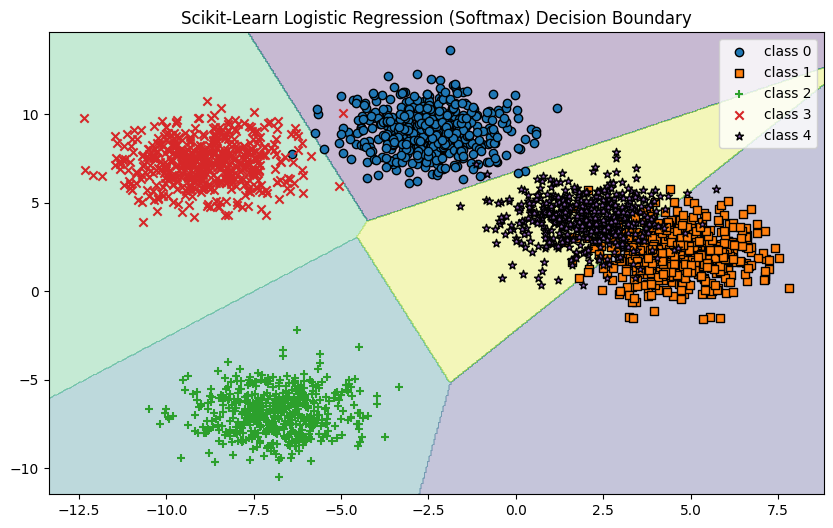

Accuracy Score: 0.9676


In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X, y)

# Predictions for the mesh grid
Z_sk = model.predict(grid)
Z_sk = Z_sk.reshape(xx.shape)

# Plotting the result
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_sk, alpha=0.3)
for i in range(5):
    plt.scatter(
        X[y == i, 0],
        X[y == i, 1],
        marker=markers[i],
        label=f'class {i}',
        edgecolors='black'
    )
plt.legend()
plt.title("Scikit-Learn Logistic Regression (Softmax) Decision Boundary")
plt.show()

print(f"Accuracy Score: {model.score(X, y):.4f}")

In [37]:
# Calculate accuracy for the manual implementation
y_pred = predict(Xbar, W)
manual_accuracy = np.mean(y_pred == y)

print(f"Manual Softmax Accuracy: {manual_accuracy:.4f}")
print(f"Scikit-learn Accuracy: {model.score(X, y):.4f}")

Manual Softmax Accuracy: 0.9600
Scikit-learn Accuracy: 0.9676
